In [1]:
import os, sys
os.environ['VXM_BACKEND'] = 'pytorch'

sys.path = [p for p in sys.path if p != r'C:\Users\ri0151fv\Saito\voxelmorph']
sys.path.insert(0, r'C:\Users\ri0151fv\Saito')

import torch
print("torch:", torch.__file__)

import voxelmorph as vxm
print("vxm:", vxm.__file__)
print(vxm.networks)

import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim
import neurite as ne
import scipy.ndimage

torch: c:\Users\ri0151fv\AppData\Local\anaconda3\envs\vxm310\lib\site-packages\torch\__init__.py
backend:pytorch
Pytorch
vxm: C:\Users\ri0151fv\Saito\voxelmorph\__init__.py
<module 'voxelmorph.torch.networks' from 'C:\\Users\\ri0151fv\\Saito\\voxelmorph\\torch\\networks.py'>
backend:pytorch
Pytorch


In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


In [4]:
# 画像を読み込み
x_train = np.load('Data/TrainData_NoBed.npz')['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))

print('Resized train vol_shape:', x_train.shape[1:])
print('Resized train shape:', x_train.shape)

Resized train vol_shape: (128, 256, 256)
Resized train shape: (400, 128, 256, 256)


In [5]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [6]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 128, 256, 256])
Fixed Images Shape: torch.Size([2, 1, 128, 256, 256])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 128, 256, 256])
Zero Gradient Shape: (2, 128, 256, 256, 3)


In [7]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    y_true = y_true.to(device)
    y_pred = y_pred.to(device)
    mse = mse_loss(y_true, y_pred)
    return mse

def lncc_loss(I, J, window=9, eps=1e-5):
    # I, J: (B, 1, D, H, W)
    padding = window // 2
    weight = torch.ones(1, 1, window, window, window, device=I.device)

    I2 = I * I
    J2 = J * J
    IJ = I * J

    I_sum = F.conv3d(I, weight, padding=padding)
    J_sum = F.conv3d(J, weight, padding=padding)
    I2_sum = F.conv3d(I2, weight, padding=padding)
    J2_sum = F.conv3d(J2, weight, padding=padding)
    IJ_sum = F.conv3d(IJ, weight, padding=padding)

    win_size = window ** 3
    u_I = I_sum / win_size
    u_J = J_sum / win_size

    cross = IJ_sum - u_J * I_sum - u_I * J_sum + u_I * u_J * win_size
    I_var = I2_sum - 2 * u_I * I_sum + u_I * u_I * win_size
    J_var = J2_sum - 2 * u_J * J_sum + u_J * u_J * win_size

    lncc = cross * cross / (I_var * J_var + eps)
    return -torch.mean(lncc)  # maximize LNCC → minimize -LNCC

In [8]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]


In [9]:
import voxelmorph as vxm
import inspect

print(vxm.__file__)
print(vxm.networks.__file__)
print([name for name in dir(vxm.networks) if "VxmDense" in name])

C:\Users\user\anaconda3\envs\nn\lib\site-packages\voxelmorph\__init__.py
C:\Users\user\anaconda3\envs\nn\lib\site-packages\voxelmorph\torch\networks.py
['VxmDense', 'VxmDense1', 'VxmDense2', 'VxmDense_128_256', 'VxmDense_128_256_256']


In [10]:
model3D = vxm.networks.VxmDense_128_256_256((128, 256, 256), nb_features, int_steps=0)
model3D.to(device)
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)
transformer256 = vxm.layers.SpatialTransformer((128, 256, 256)).to(device)

C:\Users\ri0151fv\Saito\voxelmorph\torch\networks.py
[64, 128, 128]


C:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [11]:
import math
import torch
import torch.nn.functional as F


def _haar_kernels_3d(device, dtype):
    """3次元直交Haarの8個のAnalysis/Synthesisフィルタを作成する。"""
    low = torch.tensor([1.0, 1.0], device=device, dtype=dtype) / math.sqrt(2.0)
    high = torch.tensor([1.0, -1.0], device=device, dtype=dtype) / math.sqrt(2.0)

    kernels = []
    for f_d, f_h, f_w in (
        (low, low, low),
        (low, low, high),
        (low, high, low),
        (low, high, high),
        (high, low, low),
        (high, low, high),
        (high, high, low),
        (high, high, high),
    ):
        kernel = torch.einsum('i,j,k->ijk', f_d, f_h, f_w)
        kernels.append(kernel)

    return torch.stack(kernels, dim=0).unsqueeze(1)  # (8, 1, 2, 2, 2)


def haar_wavelet_3d(x):
    """
    3次元Haar Analysisフィルタバンク。

    x: (B, 1, D, H, W)
    return: (B, 8, D/2, H/2, W/2)
    """
    if x.ndim != 5 or x.shape[1] != 1:
        raise ValueError(f'x must have shape (B, 1, D, H, W), but got {tuple(x.shape)}')

    if any(size % 2 != 0 for size in x.shape[2:]):
        raise ValueError(f'D, H, W must all be even, but got {tuple(x.shape[2:])}')

    analysis_filters = _haar_kernels_3d(x.device, x.dtype)

    # ① Analysisフィルタのみ
    y = F.conv3d(
        x,
        analysis_filters,
        stride=1
    )

    print("Analysis:", y.shape)

    # ② Downsampling
    y = y[:, :, 0::2, 0::2, 0::2]

    print("Downsample:", y.shape)

    return y


def inverse_haar_wavelet_3d(x):
    """
    3次元Haar Synthesisフィルタバンク。

    x: (B, 8, D/2, H/2, W/2)
    return: (B, 1, D, H, W)
    """
    if x.ndim != 5 or x.shape[1] != 8:
        raise ValueError(f'x must have shape (B, 8, D, H, W), but got {tuple(x.shape)}')

    synthesis_filters = _haar_kernels_3d(x.device, x.dtype)

    B, C, D, H, W = x.shape

    # ① Upsampling（偶数位置に元の値を置き，それ以外は0）
    up = torch.zeros(
        (B, C, D * 2, H * 2, W * 2),
        device=x.device,
        dtype=x.dtype
    )
    up[:, :, 0::2, 0::2, 0::2] = x

    print('Upsample:', up.shape)

    # ② Synthesisフィルタリング
    # conv_transpose3d(stride=2) と同じ処理を，0挿入後の配置として明示的に書く。
    out = torch.zeros(
        (B, 1, D * 2, H * 2, W * 2),
        device=x.device,
        dtype=x.dtype
    )

    for c in range(C):
        for kd in range(2):
            for kh in range(2):
                for kw in range(2):
                    out[:, :, kd::2, kh::2, kw::2] += (
                        up[:, c:c+1, 0::2, 0::2, 0::2]
                        * synthesis_filters[c, 0, kd, kh, kw]
                    )

    print('Synthesis:', out.shape)

    return out


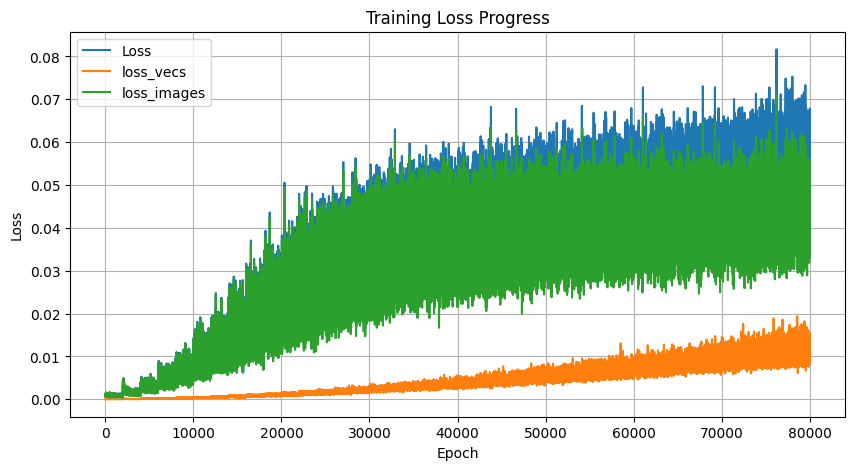

  0%|          | 91/80000 [27:48<415:44:56, 18.73s/it]

Epoch 79991/80000, Loss: 0.0575, loss_vec: 0.0116, loss_image: 0.0459, Shift Range: ±40 pixels
Epoch 79992/80000, Loss: 0.0519, loss_vec: 0.0105, loss_image: 0.0414, Shift Range: ±40 pixels
Epoch 79993/80000, Loss: 0.0513, loss_vec: 0.0088, loss_image: 0.0425, Shift Range: ±40 pixels
Epoch 79994/80000, Loss: 0.0489, loss_vec: 0.0126, loss_image: 0.0362, Shift Range: ±40 pixels
Epoch 79995/80000, Loss: 0.0539, loss_vec: 0.0106, loss_image: 0.0433, Shift Range: ±40 pixels
Epoch 79996/80000, Loss: 0.0603, loss_vec: 0.0111, loss_image: 0.0491, Shift Range: ±40 pixels
Epoch 79997/80000, Loss: 0.0569, loss_vec: 0.0114, loss_image: 0.0455, Shift Range: ±40 pixels
Epoch 79998/80000, Loss: 0.0565, loss_vec: 0.0102, loss_image: 0.0462, Shift Range: ±40 pixels
Epoch 79999/80000, Loss: 0.0570, loss_vec: 0.0119, loss_image: 0.0451, Shift Range: ±40 pixels
Epoch 80000/80000, Loss: 0.0629, loss_vec: 0.0123, loss_image: 0.0506, Shift Range: ±40 pixels


  0%|          | 92/80000 [28:05<405:06:47, 18.25s/it]

Epoch 92/80000, Loss: 0.0008, loss_vec: 0.0000, loss_image: 0.0007, Shift Range: ±1 pixels


  0%|          | 93/80000 [28:22<396:13:40, 17.85s/it]

...

  0%|          | 99/80000 [30:10<394:08:44, 17.76s/it]

Epoch 99/80000, Loss: 0.0006, loss_vec: 0.0000, loss_image: 0.0006, Shift Range: ±1 pixels


  0%|          | 99/80000 [30:28<409:53:36, 18.47s/it]

Epoch 100/80000, Loss: 0.0007, loss_vec: 0.0000, loss_image: 0.0007, Shift Range: ±1 pixels


NameError: name 'fixed_images' is not defined

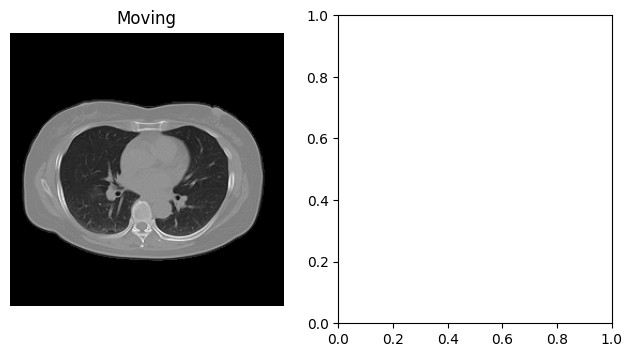

In [12]:
# NotdecoderHight
from tqdm.notebook import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt

# 3D ガウシアンフィルタを適用する関数
def gaussian_smooth_3d(tensor, kernel_size=5, sigma=1.0):
    """ 3D ガウシアンフィルタで displacement field をスムージング """
    # 3D Gaussian Kernel の作成
    from scipy.ndimage import gaussian_filter
    tensor_np = tensor.cpu().numpy()
    smoothed_np = gaussian_filter(tensor_np, sigma=[0, 0, sigma, sigma, sigma])  # チャネル方向にはフィルタ適用しない
    return torch.tensor(smoothed_np, dtype=torch.float32, device=tensor.device)


# エポック数と最小ロスの設定
epochs = 1
best_loss = float('inf')
shift_range = 1

# ロスや他のメトリクスを記録するリスト
losses = []
loss_vecs = []
loss_images = []
loss_hightVecs = []
for epoch in tqdm(range(epochs)):
    # 100エポックごとにshift_rangeを増やす
    if epoch % 2000 == 0 and epoch > 0:
        shift_range += 1
        print(f"Epoch {epoch}: Increasing shift range to ±{shift_range} pixels.")

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(
        train_batch[0], 
        dtype=torch.float32,
        device=device
    )

    # 画像サイズを設定
    B = moving_images.shape[0]
    D, H, W = 8, 16, 16 # 画像の次元

    # displacement_field をボクセルごとにランダムに作成
    displacement_field = (torch.rand((B, 3, D, H, W), dtype=torch.float32) * 2 - 1) * shift_range
    displacement_field = displacement_field.to(device)

    # 3D Gaussian Smoothing を適用
    displacement_field = gaussian_smooth_3d(displacement_field, sigma=2.0)
    displacement_field = torch.nn.functional.interpolate(displacement_field, size=(128,256,256), mode='trilinear', align_corners=False)
    displacement_field128 = torch.nn.functional.interpolate(displacement_field, size=(64,128,128), mode='trilinear', align_corners=False)

    # 位置をずらした画像を生成
    moving_images2 = transformer256(moving_images, displacement_field)

    # Wavelet 変換（前処理）
    moving_w = haar_wavelet_3d(moving_images)  # (B,8,D/2,H/2,W/2)
    moving_images2_w  = haar_wavelet_3d(moving_images2)   # (B,8,D/2,H/2,W/2)
    
    # device に戻す
    moving_w = moving_w.to(device)
    moving_images2_w  = moving_images2_w.to(device)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    Vec = model3D(moving_w, moving_images2_w)

    # Moving側の8成分すべてに同じDVFを一括適用

    moving_warped = transformer(
        moving_w,
        Vec
    )
    
    # 逆Wavelet
    transformed_image = inverse_haar_wavelet_3d(moving_warped)
    
    transformed_image = transformed_image.to(device) 

    # 損失を計算
    loss_vec = MSE_Loss(displacement_field128, Vec) * 0.01
    loss_image = MSE_Loss(moving_images2, transformed_image) * 100
    
    loss = loss_vec + loss_image

    # 逆伝播
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 1000 == 0:
        torch.save(
            {
                'epoch': epoch + 1,
                'model_state_dict': model3D.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss.detach().item(),
                'shift_range': shift_range,
            },
            'model_wavelet_pretrain_checkpoint.pth'
        )
        
    losses.append(loss.cpu().item())
    loss_vecs.append(loss_vec.cpu().item())
    loss_images.append(loss_image.cpu().item())

    # 100エポックごとにグラフを更新
    if (epoch + 1) % 100 == 0:
        # clear_output(wait=True)  # 出力をリフレッシュ
        plt.figure(figsize=(10,5))
        plt.plot(losses, label='Loss')
        plt.plot(loss_vecs, label='loss_vecs')
        plt.plot(loss_images, label='loss_images')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # エポックごとのロスの表示
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, loss_vec: {loss_vec:.4f}, loss_image: {loss_image:.4f}, Shift Range: ±{shift_range} pixels")


In [13]:
from tqdm.notebook import tqdm
print(os.getcwd())
print(os.listdir())

import glob

glob.glob("*.pth")

model3D = vxm.networks.VxmDense_128_256_256((64, 128, 128), nb_features, int_steps=0).to(device)
# model3D.load_state_dict(torch.load('a2.pth', map_location=device))
model3D.to(device)
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)


# エポック数と最小ロスの設定
epochs = 1

# ロスや他のメトリクスを記録するリスト
losses = []
mses = []
grads = []

for epoch in tqdm(range(epochs)):

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)
    fixed_images = torch.tensor(train_batch[1], dtype=torch.float32).to(device)
    
    # Wavelet 変換（前処理）
    moving_w = haar_wavelet_3d(moving_images).to(device)  # (B,8,D/2,H/2,W/2)
    fixed_w  = haar_wavelet_3d(fixed_images).to(device)   # (B,8,D/2,H/2,W/2)
    
    # 勾配を初期化
    optimizer.zero_grad()


    # 順伝播
    Vec = model3D(moving_w, fixed_w)
        
    # --- 各 Wavelet 成分を変形 ---
    moving_LLL = transformer(moving_w[:, 0:1], Vec)
    moving_LLH = transformer(moving_w[:, 1:2], Vec)
    moving_LHL = transformer(moving_w[:, 2:3], Vec)
    moving_LHH = transformer(moving_w[:, 3:4], Vec)
    moving_HLL = transformer(moving_w[:, 4:5], Vec)
    moving_HLH = transformer(moving_w[:, 5:6], Vec)
    moving_HHL = transformer(moving_w[:, 6:7], Vec)
    moving_HHH = transformer(moving_w[:, 7:8], Vec)
    
    moving_warped = torch.cat(
        [
            moving_LLL, moving_LLH, moving_LHL, moving_LHH,
            moving_HLL, moving_HLH, moving_HHL, moving_HHH
        ],
        dim=1
    )  # (B,8,D/2,H/2,W/2)
    
    # 逆Wavelet
    transformed_image = inverse_haar_wavelet_3d(moving_warped)
    
    transformed_image = transformed_image.to(device)    
    # 損失を計算
    loss = MSE_Loss(fixed_images, transformed_image)

    # 逆伝播
    loss.backward()
    optimizer.step()

    # モデルを保存
    torch.save(model3D.state_dict(), 'model_wavelet_128_256_256.pth')

    # エポックごとのロスを保存
    losses.append(loss.cpu().item())
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")
    
    # 100エポックごとに画像を表示
    if (epoch + 1) % 100 == 0:
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(moving_images[0, 0, 64].detach().cpu(), cmap="gray")
        plt.title("Moving")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(fixed_images[0, 0, 64].detach().cpu(), cmap="gray")
        plt.title("Fixed")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(transformed_image[0, 0, 64].detach().cpu(), cmap="gray")
        plt.title("Warped")
        plt.axis("off")

        plt.show()

D:\Saito
['            .pth', '         .pth', '.git', '.gitignore', '.ipynb_checkpoints', '128model_Test.ipynb', '128model_Train.ipynb', '128model_Train_inverse-consistency constraint.ipynb', '256_128model_Test.ipynb', '256_128model_Train.ipynb', 'a.pth', 'a2.pth', 'Data', 'Data.zip']
[64, 128, 128]


  0%|          | 0/30000 [00:00<?, ?it/s]

C:\Users\user\AppData\Local\Temp\ipykernel_18392\2295694104.py:26: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  moving_images = torch.tensor(train_batch[0], dtype=torch.float32)
C:\Users\user\AppData\Local\Temp\ipykernel_18392\2295694104.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  fixed_images = torch.tensor(train_batch[1], dtype=torch.float32)


Epoch 1/30000, Loss: 0.0441
Epoch 2/30000, Loss: 0.0273
Epoch 3/30000, Loss: 0.0375
Epoch 4/30000, Loss: 0.0367
Epoch 5/30000, Loss: 0.0397
Epoch 6/30000, Loss: 0.0282
Epoch 7/30000, Loss: 0.0288
Epoch 8/30000, Loss: 0.0405
Epoch 9/30000, Loss: 0.0304
Epoch 10/30000, Loss: 0.0208
Epoch 11/30000, Loss: 0.0338
Epoch 12/30000, Loss: 0.0435
Epoch 13/30000, Loss: 0.0448
Epoch 14/30000, Loss: 0.0324
Epoch 15/30000, Loss: 0.0219
Epoch 16/30000, Loss: 0.0338
Epoch 17/30000, Loss: 0.0431
Epoch 18/30000, Loss: 0.0277
Epoch 19/30000, Loss: 0.0297
Epoch 20/30000, Loss: 0.0243
Epoch 21/30000, Loss: 0.0403
Epoch 22/30000, Loss: 0.0409
Epoch 23/30000, Loss: 0.0245
Epoch 24/30000, Loss: 0.0323
Epoch 25/30000, Loss: 0.0305
Epoch 26/30000, Loss: 0.0400
Epoch 27/30000, Loss: 0.0353
Epoch 28/30000, Loss: 0.0202
Epoch 29/30000, Loss: 0.0477
Epoch 30/30000, Loss: 0.0246
Epoch 31/30000, Loss: 0.0348
Epoch 32/30000, Loss: 0.0262
Epoch 33/30000, Loss: 0.0551
Epoch 34/30000, Loss: 0.0256
Epoch 35/30000, Loss: 0

In [16]:
import os

for drive in ["D:\\", "C:\\"]:
    for root, dirs, files in os.walk(drive):
        for file in files:
            if "wavelet" in file.lower() and file.endswith(".pth"):
                print(os.path.join(root, file))

D:\Yamato\model_VXM_3D_MInoBed_WaveletEncorder.pth
D:\Yamato\model_VXM_3D_MInoBed_WaveletTest.pth
D:\Yamato\model_VXM_3D_weights_Wavelet.pth
C:\Users\user\OneDrive\ドキュメント\model_VXM_3D_MInoBed_WaveletTest.pth


In [18]:
import torch, os

save_path = r"D:\Saito\model_wavelet_128_256_256.pth"
torch.save(model3D.state_dict(), save_path)

print(os.path.exists(save_path))
print(save_path)

True
D:\Saito\model_wavelet_128_256_256.pth


In [22]:
data = np.load("Data/TrainData_NoBed.npz")
print(data.files)

for k in data.files:
    print(k, data[k].shape, data[k].dtype)

['Train']
Train (128, 256, 256, 400) float64


In [23]:
# 実CT画像で Haar → 逆Haar の完全再構成を確認

print("x_train shape:", x_train.shape)

x = x_train[0:1]  # 実CTを1症例だけ取り出す

# (N, D, H, W) → (N, 1, D, H, W)
x = torch.tensor(x, dtype=torch.float32).unsqueeze(1).to(device)

w = haar_wavelet_3d(x)
x_rec = inverse_haar_wavelet_3d(w)

print("元画像:", x.shape)
print("Wavelet後:", w.shape)
print("逆変換後:", x_rec.shape)

mean_error = torch.mean(torch.abs(x - x_rec)).item()
max_error = torch.max(torch.abs(x - x_rec)).item()

print("mean error:", mean_error)
print("max error:", max_error)

x_train shape: (400, 128, 256, 256)
元画像: torch.Size([1, 1, 128, 256, 256])
Wavelet後: torch.Size([1, 8, 64, 128, 128])
逆変換後: torch.Size([1, 1, 128, 256, 256])
mean error: 1.3736158877009075e-08
max error: 2.384185791015625e-07
